In [ ]:
Beetles <- read.csv(url("https://whitlockschluter3e.zoology.ubc.ca/Data/chapter15/chap15q29Tribolium.csv"))
Beetles

treatment,total_offspring
<chr>,<dbl>
female-biased,80.16
female-biased,6.00
female-biased,53.17
female-biased,121.34
female-biased,69.00
female-biased,57.82
female-biased,62.16
female-biased,66.50
male-biased,118.00


In [ ]:
Beetlesaov <- aov(total_offspring ~ treatment, data = Beetles)
summary(Beetlesaov)

            Df Sum Sq Mean Sq F value   Pr(>F)    
treatment    2  23898   11949   12.83 0.000203 ***
Residuals   22  20489     931                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

1: A. Sex ratio treatment affects the mean number of offspring per
female as indicated by a P-value of 0.000203 < 0.05 i.e. statistically significant. In other words, at least one treatment mean is different from the others. Therefore, we reject the null hypothesis.

In [ ]:
TukeyHSD(Beetlesaov)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = total_offspring ~ treatment, data = Beetles)

$treatment
                               diff       lwr       upr     p adj
male-biased-female-biased  72.03681  34.78612 109.28749 0.0002118
unbiased-female-biased     19.35125 -18.97939  57.68189 0.4273901
unbiased-male-biased      -52.68556 -89.93624 -15.43487 0.0048695


B. The male-biased-female-biased and unbiased-male-biased treatment means are different from the others as indicated by post-hoc test P-values of 0.00021 and 0.0049 < 0.05 i.e. statistically significant. Therefore, we reject the null hypothesis.

In [ ]:
mosquitos <- read.csv(url("https://whitlockschluter3e.zoology.ubc.ca/Data/chapter15/chap15q23MalariaFungusVenom.csv"))
head(mosquitos)

,treatmentGroup,logSporozoiteNumbers
,<chr>,<dbl>
1,Control,7.2
2,Control,7.4
3,Control,7.4
4,Control,7.7
5,Control,7.9
6,Control,7.9


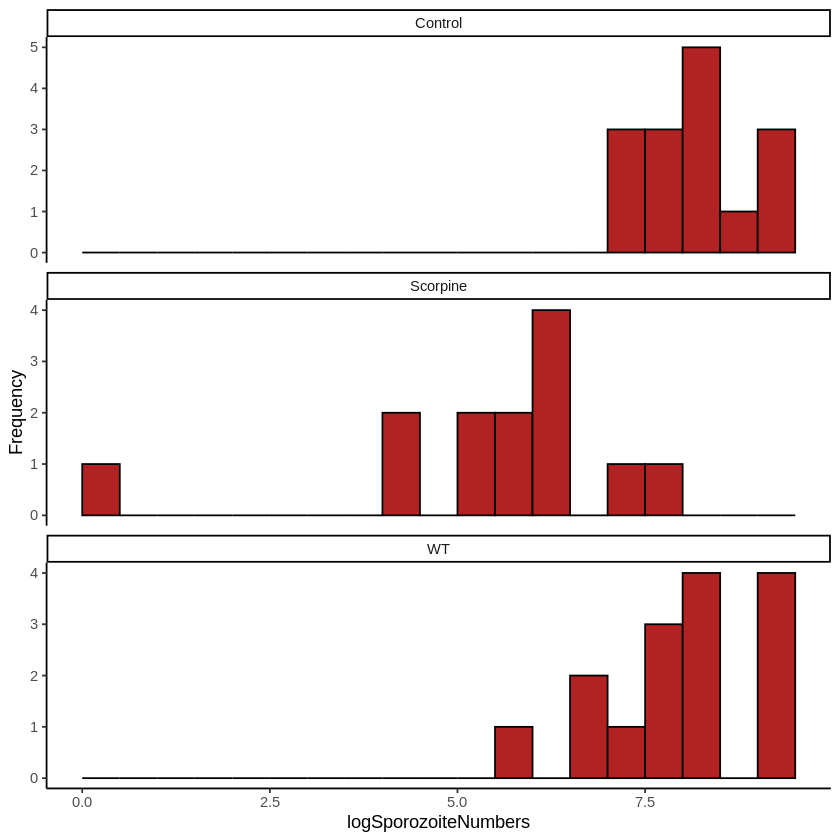

In [ ]:
mosquitos$treatmentGroup <- factor(mosquitos$treatmentGroup, 
    levels = c("Control", "Scorpine", "WT"))

ggplot(mosquitos, aes(x = logSporozoiteNumbers)) + 
    geom_histogram(fill = "firebrick", col = "black", binwidth = 0.5, 
        boundary = 0, closed = "left") +
    facet_wrap( ~ treatmentGroup, ncol = 1, scales = "free_y") +
    labs(x = "logSporozoiteNumbers", y = "Frequency") + 
    theme_classic()

2: A. The suggested pattern is that the logSporozoiteNumbers distribution for the Control group is somewhat normal whereas for Scorpine, there's an extreme outlier on the left so not normal. For the Wild Type, the distribution is also not normal as it's left skewed. In such cases, the non-parametric approach is recommended when analyzing data that is not normal.

In [ ]:
kruskal.test(logSporozoiteNumbers ~ treatmentGroup, data = mosquitos) 


	Kruskal-Wallis rank sum test

data:  logSporozoiteNumbers by treatmentGroup
Kruskal-Wallis chi-squared = 22.874, df = 2, p-value = 1.079e-05


B. The mean sporozoite count is different among these three groups as the Kruskal-Wallis test P-value of 1.079e-05 < 0.05 is statistically significant and we reject the null hypothesis. In other words, at least one treatment mean is different from the others.

In [ ]:
pairwise.wilcox.test(mosquitos$logSporozoiteNumbers, mosquitos$treatmentGroup, p.adj='bonferroni', exact=F)


	Pairwise comparisons using Wilcoxon rank sum test with continuity correction 

data:  mosquitos$logSporozoiteNumbers and mosquitos$treatmentGroup 

         Control Scorpine
Scorpine 4.4e-05 -       
WT       1.00000 0.00035 

P value adjustment method: bonferroni 

C. The Scorpine is different from the Control as well as WT which is indicated by pairwise test P-values of 4.4e-05 and 0.00035 < 0.05 i.e. statistically significant. Therefore, we reject the null hypothesis.

In [ ]:
read_sheet(https://docs.google.com/spreadsheets/d/12zN9vjKak4_e1-MMFqg-qitvUz-q48EhutWYjchpDBM/edit#gid=500254812)